In [17]:
import torch
import torchvision
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import os
import time


#environment set up
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())



PyTorch version: 2.2.2
Torchvision version: 0.17.2
CUDA is available: False


In [5]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
mask_generator = SamAutomaticMaskGenerator(sam)

In [28]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [6]:
#plot les masques
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [7]:
def calculate_circularity(mask):
    """
    Calculate the circularity of a segmented region using mask properties.

    Args:
        mask: Dictionary containing mask properties, including 'segmentation' (binary array) and 'area'.

    Returns:
        Circularity value (float) or None if the mask is invalid.
    """
    area = mask.get('area', None)
    if area is None or area == 0:
        print("Invalid or zero area in mask.")
        return None

    segmentation = mask['segmentation'].astype(np.uint8)
    contours, _ = cv2.findContours(segmentation, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        print("No contours found in the mask.")
        return None

    # Utiliser le plus grand contour pour calculer le périmètre
    largest_contour = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(largest_contour, True)

    if perimeter == 0:
        print("Perimeter is zero, cannot calculate circularity.")
        return None

    # Calculer la circularité
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    return circularity

def calculate_centroid(bbox):
    """
    Calcule le centroïde d'une boîte englobante (bbox).
    
    Args:
        bbox: Liste [x_min, y_min, width, height].
    
    Returns:
        Tuple (x_centroid, y_centroid).
    """
    x_min, y_min, width, height = bbox
    x_centroid = x_min + width / 2
    y_centroid = y_min + height / 2
    return x_centroid, y_centroid

def is_duplicate(mask1, mask2):
    """
    Vérifie si deux masques sont des doublons en comparant leurs centroïdes.
    
    Args:
        mask1: Premier masque (dictionnaire avec 'bbox').
        mask2: Deuxième masque (dictionnaire avec 'bbox').
    
    Returns:
        True si les masques sont des doublons, False sinon.
    """
    centroid1 = calculate_centroid(mask1['bbox'])
    centroid2 = calculate_centroid(mask2['bbox'])
    distance = np.sqrt((centroid1[0] - centroid2[0])**2 + (centroid1[1] - centroid2[1])**2)
    margin = max(mask1['bbox'][2], mask2['bbox'][2]) * 0.2
    return distance <= margin

# prompt: calculer la fluorescence moyenne dans une cellule sur fluo.tif, délimitée par le masque fait à partir de droplet.png


def calculate_average_fluorescence(fluo_image, mask):
    """Calculates the average fluorescence intensity within a given mask.

    Args:
        fluo_image: NumPy array representing the fluorescence image.
        mask: NumPy array representing the binary mask (0 or 1).

    Returns:
        The average fluorescence intensity within the mask, or NaN if the mask is empty.
    """
    masked_fluorescence = fluo_image[mask > 0]
    if len(masked_fluorescence) == 0:
        return np.nan  # Return NaN if the mask doesn't cover any pixels
    return np.mean(masked_fluorescence)




In [8]:
def plot_fluorescences(fluorescences):
    # Tracer la fluorescence en fonction du temps
    plt.figure(figsize=(10, 6))
    for fluorescence_data in fluorescences:
        for mask_fluorescence in fluorescence_data:
            timepoints, fluorescence_values = zip(*fluorescence_data[mask_fluorescence])
            plt.plot(timepoints, fluorescence_values)

    plt.xlabel("Timepoint")
    plt.ylabel("Average Fluorescence")
    plt.title("Fluorescence moyenne par masque en fonction du temps")
    plt.show()

In [14]:
def get_data_path_from_tests(file_path):
    # Construire le chemin absolu dynamiquement
    current_dir = os.getcwd()  # Répertoire courant
    parent_dir = os.path.dirname(current_dir)  # Répertoire parent
    real_path = os.path.join(parent_dir, "data/", file_path)

    # Vérifier si le fichier existe
    if os.path.exists(real_path):
        return real_path
    else:
        print(f"Erreur : Le fichier n'existe pas à l'emplacement {real_path}")


In [ ]:
def single_roi_fluo(dic_image, image_path1, image_path2, t1, t2, roi_coords, mask_generator, circularity_threshold=0.85, margin=2):
    """
    Traite une seule ROI dans une image DIC et calcule la fluorescence moyenne dans cette ROI.

    Args:
        dic_image: Image DIC sous forme de tableau NumPy.
        image_path1: Préfixe du chemin des images de fluorescence.
        image_path2: Suffixe du chemin des images de fluorescence.
        t1: Premier point temporel.
        t2: Dernier point temporel.
        roi_coords: Coordonnées de la ROI (x_min, y_min, x_max, y_max).
        mask_generator: Générateur de masques (par exemple, SamAutomaticMaskGenerator).
        circularity_threshold: Seuil minimal de circularité pour accepter un masque.
        margin: Marge pour considérer qu'un masque est trop proche des bords.

    Returns:
        Dictionnaire contenant les données de fluorescence moyenne pour chaque masque en fonction du temps.
    """
    x_min, y_min, x_max, y_max = roi_coords
    image = dic_image
    # Extraire la ROI
    roi = image[y_min:y_max, x_min:x_max]

    print(f"Generating masks for ROI at coordinates: {roi_coords}")

    # Générer les masques pour la ROI
    start_time = time.time()
    masks = mask_generator.generate(roi)
    end_time = time.time()
    valid_masks = []
    print(f"Generated {len(masks)} masks in {end_time - start_time:.2f} seconds.")

    for mask in masks:
        # Vérifier la non juxtaposition avec les bords de la ROI
        if mask['bbox'][0] < margin or mask['bbox'][1] < margin or \
           mask['bbox'][0] + mask['bbox'][2] > roi.shape[1] - margin or \
           mask['bbox'][1] + mask['bbox'][3] > roi.shape[0] - margin:
            continue

        # Vérifier la circularité
        circularity = calculate_circularity(mask)
        if circularity is None or circularity < circularity_threshold:
            continue

        valid_masks.append(mask)
    print(f"Selected {len(valid_masks)} valid masks.")
    del masks
    # Calculer la fluorescence pour chaque point temporel
    fluorescence_data = {}
    for timepoint in range(t1, t2 +1):
        print(f"Processing timepoint {timepoint}...")
        fluo_image_path = get_data_path_from_tests(image_path1 + f"t0{timepoint:02d}" + image_path2)
        fluo_image = cv2.imread(fluo_image_path)
        if fluo_image is None:
            print(f"Image de fluorescence non trouvée : {fluo_image_path}")
            continue
        fluo_image_roi = fluo_image[y_min:y_max, x_min:x_max]
        for index, mask in enumerate(valid_masks):
            mask_segmentation = mask['segmentation']
            average_fluorescence = calculate_average_fluorescence(fluo_image_roi, mask_segmentation)
            if average_fluorescence is not None:
                if index not in fluorescence_data:
                    fluorescence_data[index] = []
                fluorescence_data[index].append((timepoint, average_fluorescence))
    del valid_masks
    return fluorescence_data


In [ ]:
def process_fluo_image(dic_image_path, image_path1, image_path2, t1, t2, roi_size, mask_generator, circularity_threshold=0.85, margin=2):
    """
    Parcourt une image entière avec des ROIs, génère des masques pour chaque ROI, calcule la fluorescence moyenne
    pour chaque masque en fonction du temps, puis libère les données des masques avant de passer à la ROI suivante.

    Args:
        image_path: Chemin de l'image DIC.
        t1: Premier point temporel (ex: 75).
        t2: Dernier point temporel (ex: 99).
        roi_size: Taille des ROIs (largeur, hauteur).
        mask_generator: Générateur de masques (par exemple, SamAutomaticMaskGenerator).
        circularity_threshold: Seuil minimal de circularité pour accepter un masque.
        margin: Marge pour considérer qu'un masque est trop proche des bords.

    Returns:
        L'ensemble des fluorescences.
    """
    image = cv2.imread(dic_image_path)
    if image is None:
        print(f"Erreur : Impossible de lire l'image {dic_image_path}")
        return

    image_height, image_width = image.shape[:2]
    roi_width, roi_height = roi_size

    # Dictionnaire pour stocker les fluorescences par masque
    total_fluorescence = []

    # Parcourir l'image avec des ROIs
    for y in range(0, image_height, roi_height):
        for x in range(0, image_width, roi_width):
            roi_coords = (x, y, min(x + roi_width, image_width), min(y + roi_height, image_height))
            print(f"Traitement de la ROI : x_min={roi_coords[0]}, y_min={roi_coords[1]}, x_max={roi_coords[2]}, y_max={roi_coords[3]}")
            fluorescence_data = single_roi_fluo(image, image_path1, image_path2, t1, t2, roi_coords, mask_generator, circularity_threshold, margin)
            if fluorescence_data is not None:
                total_fluorescence.append(fluorescence_data)
                del fluorescence_data
    return total_fluorescence
            
            


In [ ]:
test_image = cv2.imread(image_path)
height, width = test_image.shape[:2]
test_image = cv2.resize(test_image, (width // 7, height // 7))
#save image
cv2.imwrite("test_image.png", test_image)



True

In [ ]:
image_path1 = "data/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_"
image_path2 = "_EGFP_ORG.tif"
t1 = 90
t2 = 99
roi_size = (4000, 3000)

In [ ]:

fluorescences = process_fluo_image(image_path, t1, t2, roi_size, mask_generator, circularity_threshold=0.85, margin=2)



Traitement de la ROI : x_min=0, y_min=0, x_max=4000, y_max=3000
Traitement de la ROI : x_min=0, y_min=0, x_max=4000, y_max=3000
Nombre de masques valides : 319
Traitement de la ROI : x_min=4000, y_min=0, x_max=7104, y_max=3000
Traitement de la ROI : x_min=4000, y_min=0, x_max=7104, y_max=3000
Nombre de masques valides : 227
Traitement de la ROI : x_min=0, y_min=3000, x_max=4000, y_max=4500
Traitement de la ROI : x_min=0, y_min=3000, x_max=4000, y_max=4500
Nombre de masques valides : 138
Traitement de la ROI : x_min=4000, y_min=3000, x_max=7104, y_max=4500
Traitement de la ROI : x_min=4000, y_min=3000, x_max=7104, y_max=4500
Nombre de masques valides : 114


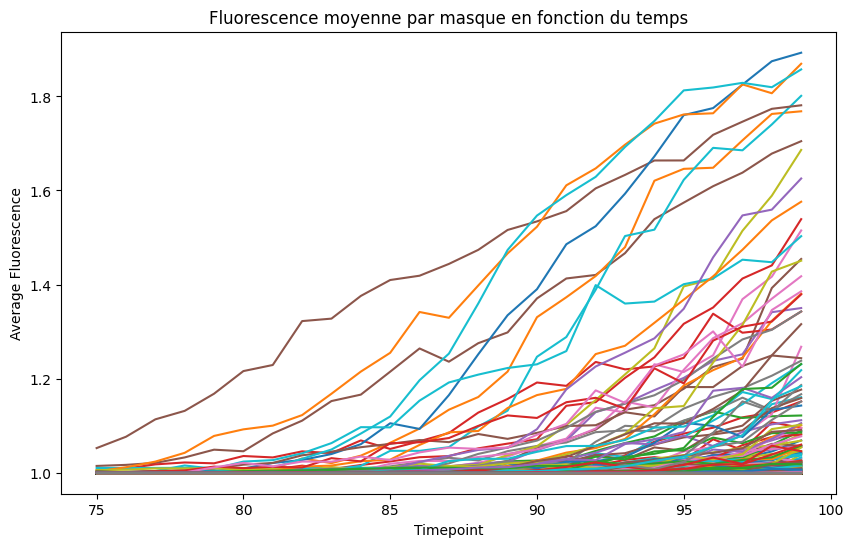

In [ ]:
plot_fluorescences(fluorescences)

In [ ]:
image_path1 = "SBW25WTGFP_CAAIPTG_1_100cell_droplet-04/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_"
image_path2 = "_EGFP_ORG.tif"
dic_image_path = get_data_path_from_tests("SBW25WTGFP_CAAIPTG_1_100cell_droplet-04/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_t097_DIC II 40x_ORG.tif")

t1 = 90
t2 = 99
roi_size = (2600, 1700)

In [32]:
fluorescences2 = process_fluo_image(dic_image_path, image_path1, image_path2, t1, t2, roi_size, mask_generator, circularity_threshold=0.85, margin=2)

Traitement de la ROI : x_min=0, y_min=0, x_max=2600, y_max=1700
Generating masks for ROI at coordinates: (0, 0, 2600, 1700)
Generated 191 masks in 132.16 seconds.
Selected 107 valid masks.
Processing timepoint 90...
Processing timepoint 91...
Processing timepoint 92...
Processing timepoint 93...
Processing timepoint 94...
Processing timepoint 95...
Processing timepoint 96...
Processing timepoint 97...
Processing timepoint 98...
Processing timepoint 99...
Traitement de la ROI : x_min=2600, y_min=0, x_max=5200, y_max=1700
Generating masks for ROI at coordinates: (2600, 0, 5200, 1700)
Generated 186 masks in 139.92 seconds.
Selected 97 valid masks.
Processing timepoint 90...
Processing timepoint 91...
Processing timepoint 92...
Processing timepoint 93...
Processing timepoint 94...
Processing timepoint 95...
Processing timepoint 96...
Processing timepoint 97...
Processing timepoint 98...
Processing timepoint 99...
Traitement de la ROI : x_min=5200, y_min=0, x_max=7104, y_max=1700
Generating

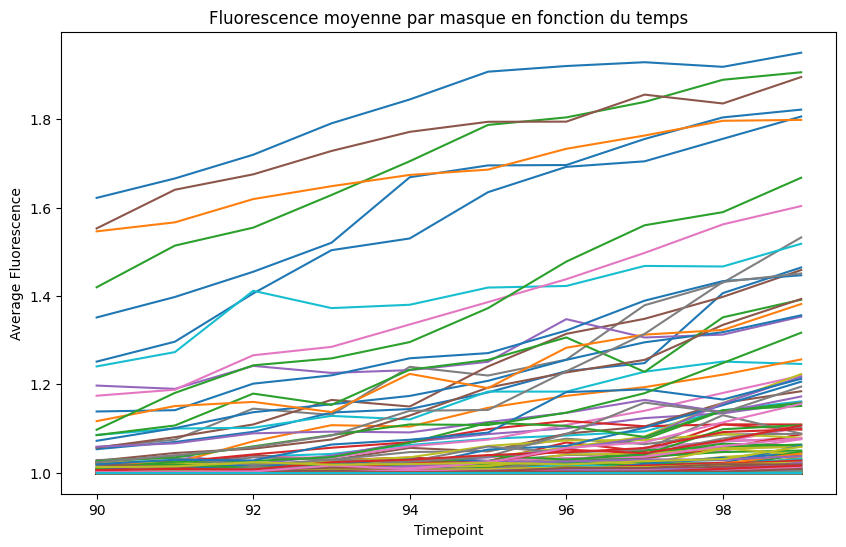

In [33]:
plot_fluorescences(fluorescences2)